In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import time

In [ ]:
use_cuda = True

if use_cuda and torch.cuda.is_available():
  device = torch.device('cuda:1')
else:
  device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cuda


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- Step 1: Loading and Preparing Metadata ---")
# Adjust path if your file is in a folder or root
metadata_path = 'balanced_dataset/balanced_metadata.csv' 
print(f"Reading {metadata_path}...")
df = pd.read_csv(metadata_path)

print("Encoding labels...")
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
classes = tuple(le.classes_)
# Create a dictionary to show which number corresponds to which disease
class_mapping = dict(zip(range(len(classes)), classes))
print(f"Detected {len(classes)} classes: {class_mapping}")

print("Splitting data into 80% Training and 20% Testing...")
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# 2. Define the Custom Dataset Class
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['path'].replace('\\', os.sep)
        image = Image.open(img_path).convert('RGB')
        label = int(self.dataframe.iloc[index]['label'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("\n--- Step 2: Defining Transforms and Datasets ---")
print("Setting resolution to 224x224 and applying ImageNet normalization...")

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset = SkinDataset(train_df, transform=transform_train)
testset = SkinDataset(test_df, transform=transform_test)

print("\n--- Step 3: Initializing DataLoaders ---")
batch_size = 32
print(f"Setting batch size to {batch_size}...")

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

# Verify dimensions for your ResNet
c, w, h = 3, 224, 224
print(f"SUCCESS: DataLoaders are ready.")
print(f"Expected Input Shape: ({batch_size}, {c}, {w}, {h})")

print("\n--- Step 4: Sanity Check (Testing 1 Batch) ---")
# This part actually tries to load one batch to ensure paths and transforms work
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"Batch loaded successfully!")
print(f"Image batch shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Labels in this batch: {labels}")
print("Everything is ready for training.")

--- Step 1: Loading and Preparing Metadata ---
Reading balanced_dataset/balanced_metadata.csv...
Encoding labels...
Detected 7 classes: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
Splitting data into 80% Training and 20% Testing...
Training samples: 4624
Testing samples: 1156

--- Step 2: Defining Transforms and Datasets ---
Setting resolution to 224x224 and applying ImageNet normalization...

--- Step 3: Initializing DataLoaders ---
Setting batch size to 32...
SUCCESS: DataLoaders are ready.
Expected Input Shape: (32, 3, 224, 224)

--- Step 4: Sanity Check (Testing 1 Batch) ---
Batch loaded successfully!
Image batch shape: torch.Size([32, 3, 224, 224])
Labels in this batch: tensor([5, 2, 1, 0, 1, 5, 0, 5, 5, 1, 0, 3, 5, 1, 5, 0, 3, 5, 2, 4, 5, 4, 0, 5,
        1, 5, 3, 4, 0, 1, 2, 0])
Everything is ready for training.


--- Verifying 5 Random Samples ---


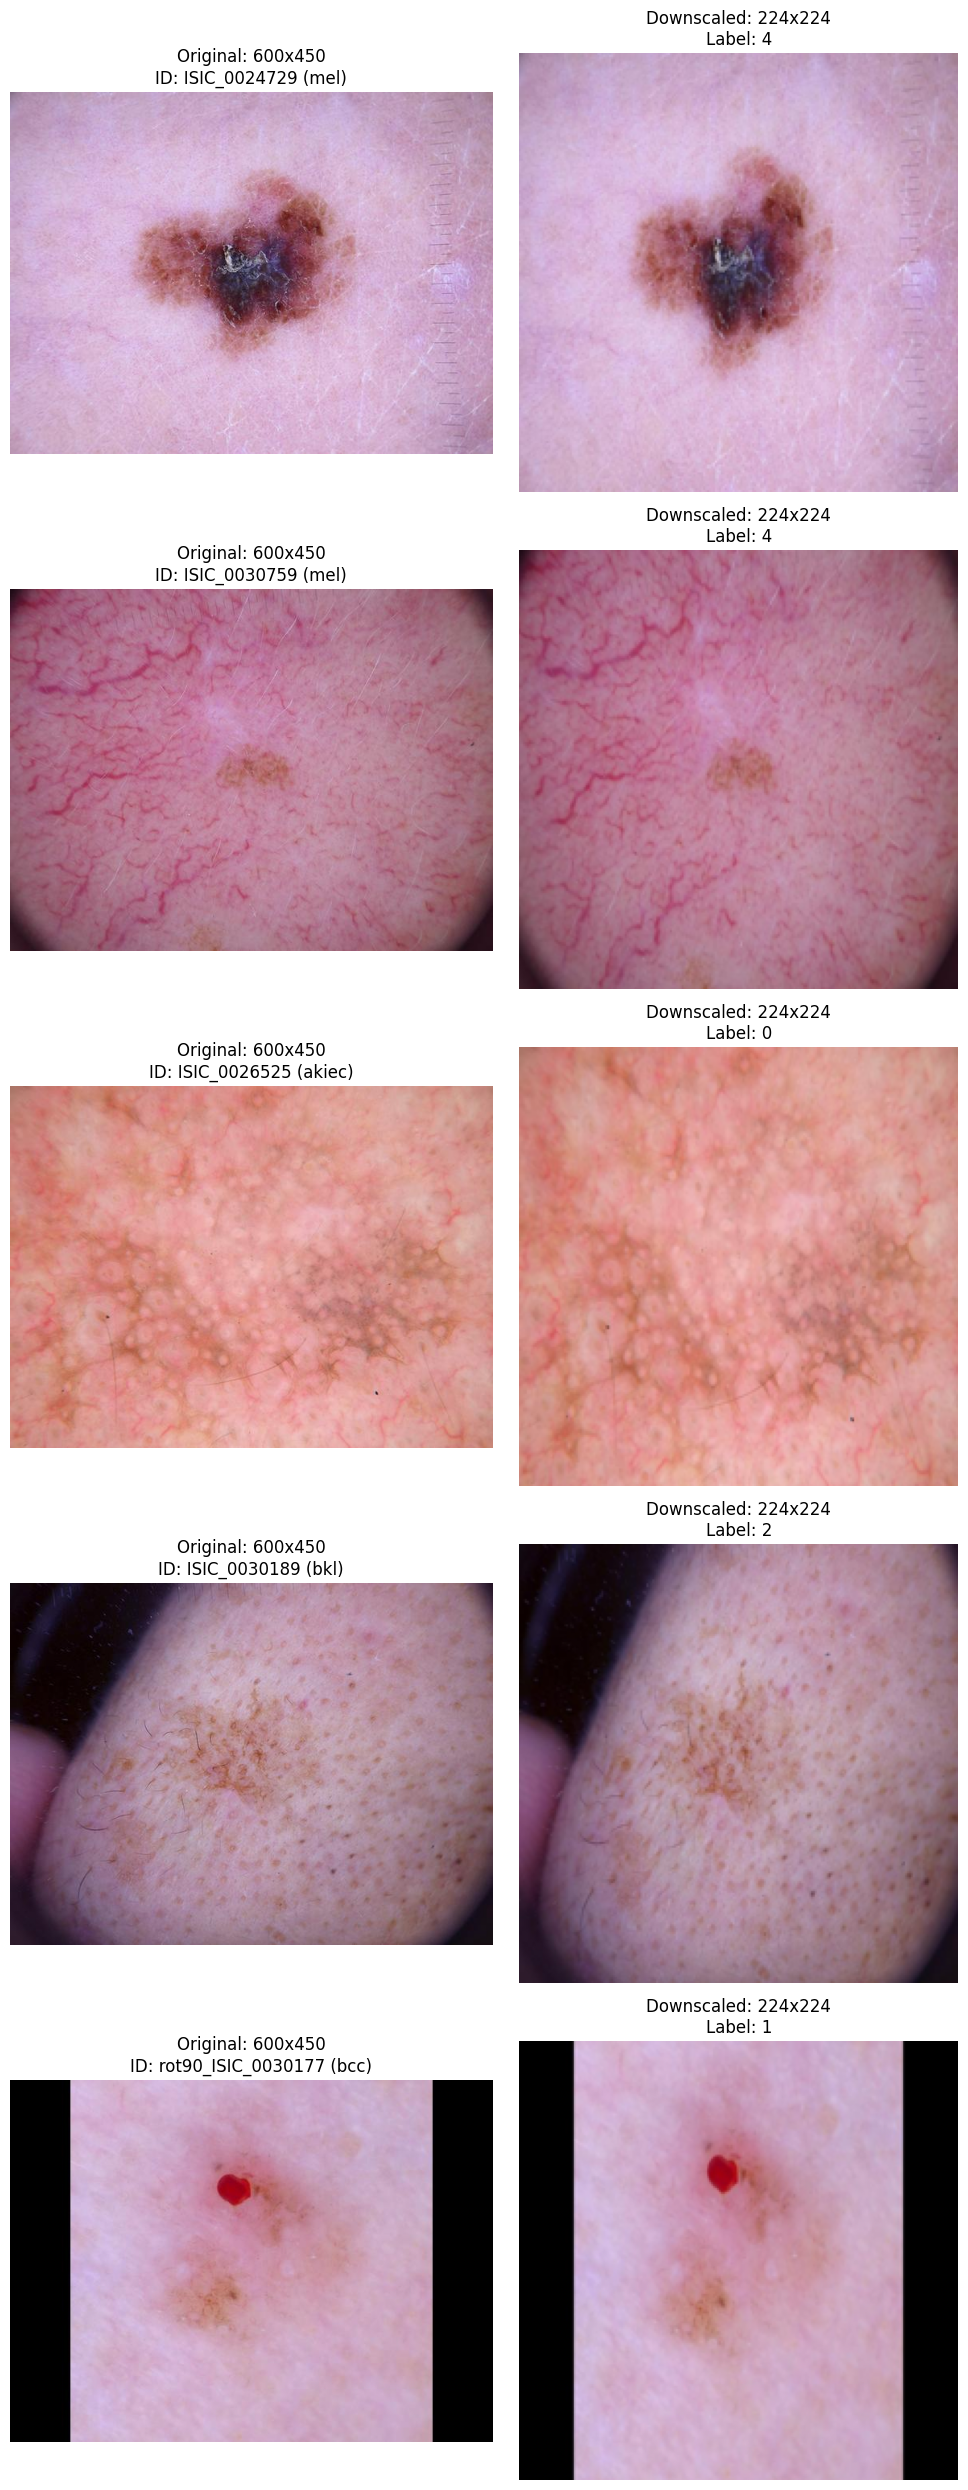

In [2]:
import matplotlib.pyplot as plt
import random

def verify_images(dataframe, num_samples=5):
    # Select random samples
    samples = dataframe.sample(num_samples)
    
    # Create the plot
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples))
    
    print(f"--- Verifying {num_samples} Random Samples ---")
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        # Load Original
        img_path = row['path'].replace('\\', os.sep)
        original_img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = original_img.size
        
        # Create Downscaled (224x224)
        downscaled_img = original_img.resize((224, 224))
        
        # Plot Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original: {orig_w}x{orig_h}\nID: {row['image_id']} ({row['dx']})")
        axes[i, 0].axis('off')
        
        # Plot Downscaled
        axes[i, 1].imshow(downscaled_img)
        axes[i, 1].set_title(f"Downscaled: 224x224\nLabel: {row['label']}")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the verification
verify_images(df, num_samples=5)

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, stride=1):
        super().__init__()

        # Layer 1
        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.batch1 = nn.BatchNorm2d(hidden_channels)
        self.relu = nn.ReLU(inplace=True)

        # Layer 2
        self.conv2 = nn.Conv2d(hidden_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.batch2 = nn.BatchNorm2d(out_channels)

        # Skip Connection (Projection if dimensions change)
        if stride != 1 or in_channels != out_channels:
            self.skip_connection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.skip_connection = nn.Sequential() # Identity

    def forward(self, x):
        identity = self.skip_connection(x)

        out = self.conv1(x)
        out = self.batch1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.batch2(out)

        out += identity  # Add skip connection
        out = self.relu(out)
        return out

In [4]:
class SkinResNet(nn.Module):
    def __init__(self, num_classes=7):
        super(SkinResNet, self).__init__()
        
        # Initial "Stem" for 224x224 images
        # Reduces 224x224 -> 56x56
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # First Residual Block
        # input: 64 channels, output: 64 channels
        self.layer1 = ResidualBlock(64, 64, 64)

        # Final Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# Initialize and print model
model = SkinResNet(num_classes=len(classes))
print(model)

SkinResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (batch1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (batch2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (skip_connection): Sequential()
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=64, out_features=7, bias=True)
)


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class ResNet(nn.Module):
    def __init__(self, in_channels, out_size):
        super().__init__()

        # --- Initial Stem (Optimized for 224x224) ---
        # Reduces input 224x224 -> 112x112
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.batch1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        # Reduces 112x112 -> 56x56
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Residual Blocks ---
        # Note: We add stride=2 when the channels increase to downsample spatially
        self.res_blocks = nn.ModuleList([
            ResidualBlock(64, 64, 64, stride=1),
            ResidualBlock(64, 64, 64, stride=1),

            ResidualBlock(64, 128, 128, stride=2), # Downsample to 28x28
            ResidualBlock(128, 128, 128, stride=1),

            ResidualBlock(128, 256, 256, stride=2), # Downsample to 14x14
            ResidualBlock(256, 256, 256, stride=1),

            ResidualBlock(256, 512, 512, stride=2), # Downsample to 7x7
            ResidualBlock(512, 512, 512, stride=1),
        ])

        # Final Classifier
        self.dense_layer = nn.Linear(512, out_size)

        # Weight Initialization
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        # 1. Stem
        x = self.conv1(x)
        x = self.batch1(x)
        x = self.relu(x)
        x = self.pool1(x)

        # 2. Residual Blocks
        for block in self.res_blocks:
            x = block(x)

        # 3. Global Average Pooling
        # x.shape[2:] automatically handles whatever the current spatial size is (e.g., 7x7)
        x = F.avg_pool2d(x, x.shape[2:])

        # 4. Flatten and Classify
        x = x.view(x.size(0), -1)
        x = self.dense_layer(x)

        return x

# Initialize the model for your 7 skin disease classes
# Use in_channels=3 for RGB images
model = ResNet(in_channels=3, out_size=len(classes))
print(f"Model initialized with {len(classes)} output classes.")

Model initialized with 7 output classes.


In [7]:
# Initialize the ResNet model
# c = 3 (RGB channels), len(classes) = 7 (from your LabelEncoder)
net = ResNet(3, len(classes)).to(device)

# Define Loss Function
# CrossEntropyLoss is ideal for the 7 mutually exclusive skin disease categories
criterion = nn.CrossEntropyLoss()

# Define Optimizer
# Starting with a learning rate of 0.001 is standard for Adam
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

print("Model, Criterion, and Optimizer initialized successfully.")

Model, Criterion, and Optimizer initialized successfully.


In [8]:
import time
import torch

# Initialize storage lists
train_losses = []
train_accuracies = []
test_accuracies = []

print(f"Starting training on {device}...")
start_total = time.time()

# 200 epochs might take a long time with 224x224; 
# you might want to start with 10-20 to see the progress.
num_epochs = 10 

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    epoch_train_loss = 0.0 
    epoch_train_correct = 0

    # --- TRAINING PHASE ---
    net.train()  
    for i, (x_batch, y_batch) in enumerate(trainloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = net(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        # Compute metrics for this batch
        y_pred_max = torch.argmax(y_pred, dim=1)
        correct = torch.sum(torch.eq(y_pred_max, y_batch)).item()
        
        epoch_train_loss += loss.item() * x_batch.size(0) 
        epoch_train_correct += correct

        # Show progress every 20 batches (adjusted frequency for 224x224 speed)
        if i % 20 == 0:
            elapsed = time.time() - start_total
            print(f'Epoch: {epoch} | Batch: {i}/{len(trainloader)} | '
                  f'Time: {elapsed:.1f}s | Loss: {loss.item():.3f} | '
                  f'Batch Acc: {correct / x_batch.size(0):.3f}')

    # Epoch-level metrics
    avg_train_loss = epoch_train_loss / len(trainset)
    avg_train_accuracy = epoch_train_correct / len(trainset)
    
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    # --- TESTING/VALIDATION PHASE ---
    correct_total = 0
    net.eval()  
    with torch.no_grad(): # Disable gradient calculation for efficiency
        for x_batch, y_batch in testloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = net(x_batch)
            y_pred_max = torch.argmax(y_pred, dim=1)
            correct_total += torch.sum(torch.eq(y_pred_max, y_batch)).item()

    test_acc = correct_total / len(testset)
    test_accuracies.append(test_acc)
    
    epoch_end_time = time.time() - epoch_start_time
    print(f'\n>>> END OF EPOCH {epoch} <<<')
    print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | '
          f'Test Acc: {test_acc:.4f} | Epoch Time: {epoch_end_time:.1f}s\n')

print(f"Total Training Time: {(time.time() - start_total) / 60:.2f} minutes")

Starting training on cuda...
Epoch: 0 | Batch: 0/145 | Time: 1.0s | Loss: 2.093 | Batch Acc: 0.031
Epoch: 0 | Batch: 20/145 | Time: 9.3s | Loss: 1.575 | Batch Acc: 0.281
Epoch: 0 | Batch: 40/145 | Time: 17.7s | Loss: 1.739 | Batch Acc: 0.344
Epoch: 0 | Batch: 60/145 | Time: 26.1s | Loss: 1.589 | Batch Acc: 0.500
Epoch: 0 | Batch: 80/145 | Time: 34.5s | Loss: 1.154 | Batch Acc: 0.625
Epoch: 0 | Batch: 100/145 | Time: 42.7s | Loss: 1.721 | Batch Acc: 0.219
Epoch: 0 | Batch: 120/145 | Time: 50.8s | Loss: 1.383 | Batch Acc: 0.406
Epoch: 0 | Batch: 140/145 | Time: 58.7s | Loss: 1.278 | Batch Acc: 0.531

>>> END OF EPOCH 0 <<<
Train Loss: 1.4652 | Train Acc: 0.4347 | Test Acc: 0.4100 | Epoch Time: 72.5s

Epoch: 1 | Batch: 0/145 | Time: 72.6s | Loss: 1.219 | Batch Acc: 0.594
Epoch: 1 | Batch: 20/145 | Time: 75.8s | Loss: 1.198 | Batch Acc: 0.438
Epoch: 1 | Batch: 40/145 | Time: 79.0s | Loss: 1.037 | Batch Acc: 0.562
Epoch: 1 | Batch: 60/145 | Time: 82.2s | Loss: 1.421 | Batch Acc: 0.469
Epoch

In [9]:
# --- Standalone Final Evaluation ---
correct_total = 0

net.eval() # Set the model to evaluation mode (deactivates dropout/batchnorm updates)

with torch.no_grad(): # Critical for saving memory during evaluation
    for i, (x_batch, y_batch) in enumerate(testloader):
        # Move data to GPU/CPU
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # Forward pass
        y_pred = net(x_batch)
        
        # Get index of the class with highest probability
        y_pred_max = torch.argmax(y_pred, dim=1)

        # Count matches
        correct_total += torch.sum(torch.eq(y_pred_max, y_batch)).item()

# Calculate final percentage
final_accuracy = correct_total / len(testset)
print(f'Final Accuracy on the test set: {final_accuracy:.3f}')

Final Accuracy on the test set: 0.599


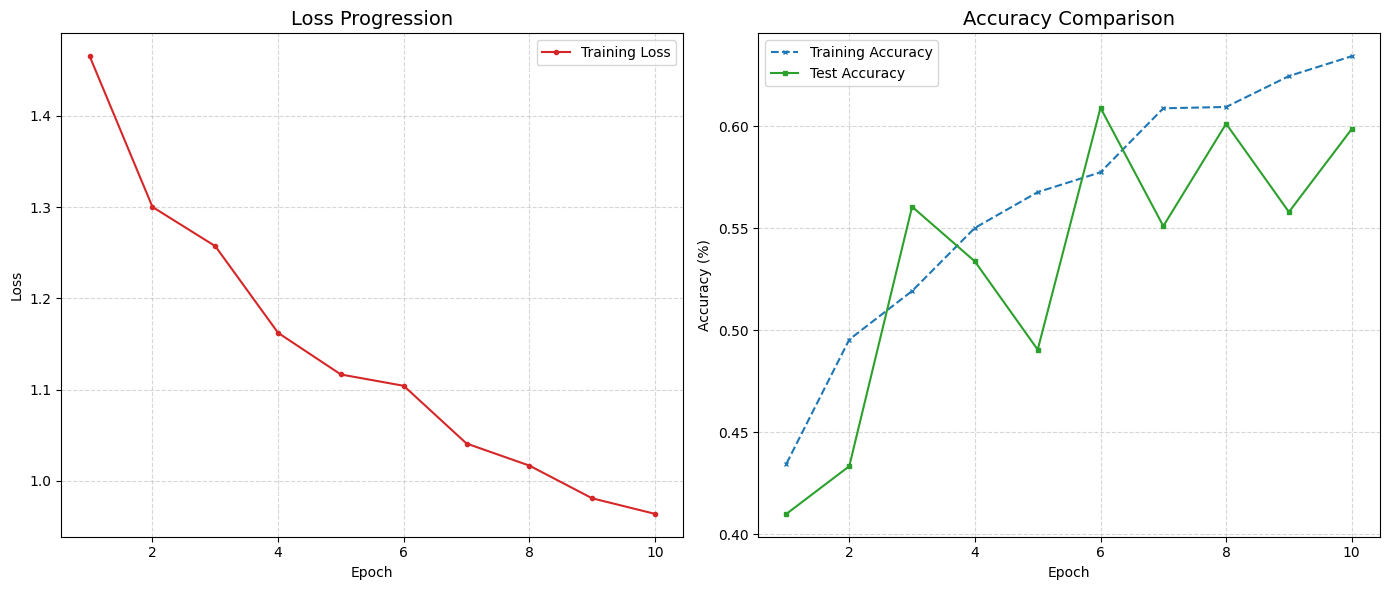


   TRAINING SUMMARY
Total Epochs Run:           10
Final Training Loss:        0.9638
Final Training Accuracy:    63.43%
Best Test Accuracy:         60.90%
Best Epoch:                 6


In [10]:
import matplotlib.pyplot as plt

# 1. Prepare data for plotting
# 'train_losses', 'train_accuracies', and 'test_accuracies' are lists from your training loop
epochs = range(1, len(train_losses) + 1)

# 2. Create the plots
plt.figure(figsize=(14, 6))

# --- Left Plot: Training Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', marker='o', linestyle='-', markersize=3, color='tab:red')
plt.title('Loss Progression', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# --- Right Plot: Training vs Test Accuracy ---
plt.subplot(1, 2, 2)
# Training Accuracy
plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='x', linestyle='--', markersize=3, color='tab:blue')
# Test Accuracy
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='s', linestyle='-', markersize=3, color='tab:green')

plt.title('Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# 3. Print Summary Statistics
print("\n" + "="*30)
print("   TRAINING SUMMARY")
print("="*30)
print(f"Total Epochs Run:           {len(epochs)}")
print(f"Final Training Loss:        {train_losses[-1]:.4f}")
print(f"Final Training Accuracy:    {train_accuracies[-1]*100:.2f}%")
print(f"Best Test Accuracy:         {max(test_accuracies)*100:.2f}%")
print(f"Best Epoch:                 {test_accuracies.index(max(test_accuracies)) + 1}")
print("="*30)